In [1]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  

In [2]:
model_folders = {
    "base": "Base",
    "sft": "SFT Only",
    "dpo": "DPO Only",
    "sft-dpo": "SFT+DPO (All)",
    "sft-dpo-unsafe": "SFT+DPO (Unsafe)"
}

base_dir = "benchmark/test" 
all_data = []

print("Gathering data from folders...")

for folder_name, model_label in model_folders.items():
    folder_path = os.path.join(base_dir, folder_name)
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    files_processed = 0
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            
            df['Refusal_Score'] = pd.to_numeric(df.get('refusal_score', 0), errors='coerce')
            df['Character_Score'] = pd.to_numeric(df.get('character_score', 0), errors='coerce')
            df['Prompt'] = df.get('prompt', '').astype(str)
            df['Query_Type'] = df.get('query_type', '').astype(str)
            df['Persona'] = df.get('persona', '').astype(str)
            df['Response'] = df.get('ai_response', '').astype(str)
            df['Model'] = model_label
            
            all_data.append(df[['Model', 'Refusal_Score', 'Character_Score', 'Prompt', 'Query_Type', 'Persona', 'Response']])
            files_processed += 1
            
        except Exception as e:
            print(f"Error reading {file}: {e}")
            
    print(f"Loaded {files_processed} files from '{folder_name}' folder.")

raw_df = pd.concat(all_data, ignore_index=True)

persona_counts = raw_df['Persona'].value_counts()

personas_90 = persona_counts[persona_counts == 450].index
personas_450 = persona_counts[persona_counts == 2250].index

df_90 = raw_df[raw_df['Persona'].isin(personas_90)]
df_450 = raw_df[raw_df['Persona'].isin(personas_450)]

print("\nData collection complete!")
print(f"Total rows ready for plotting: {len(raw_df)}")

Gathering data from folders...
Loaded 21 files from 'base' folder.
Loaded 21 files from 'sft' folder.
Loaded 21 files from 'dpo' folder.
Loaded 21 files from 'sft-dpo' folder.
Loaded 21 files from 'sft-dpo-unsafe' folder.

Data collection complete!
Total rows ready for plotting: 14850


/var/folders/vt/3mdrh98x7w19861n5z9p3nyr0000gn/T/ipykernel_41839/1402920115.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


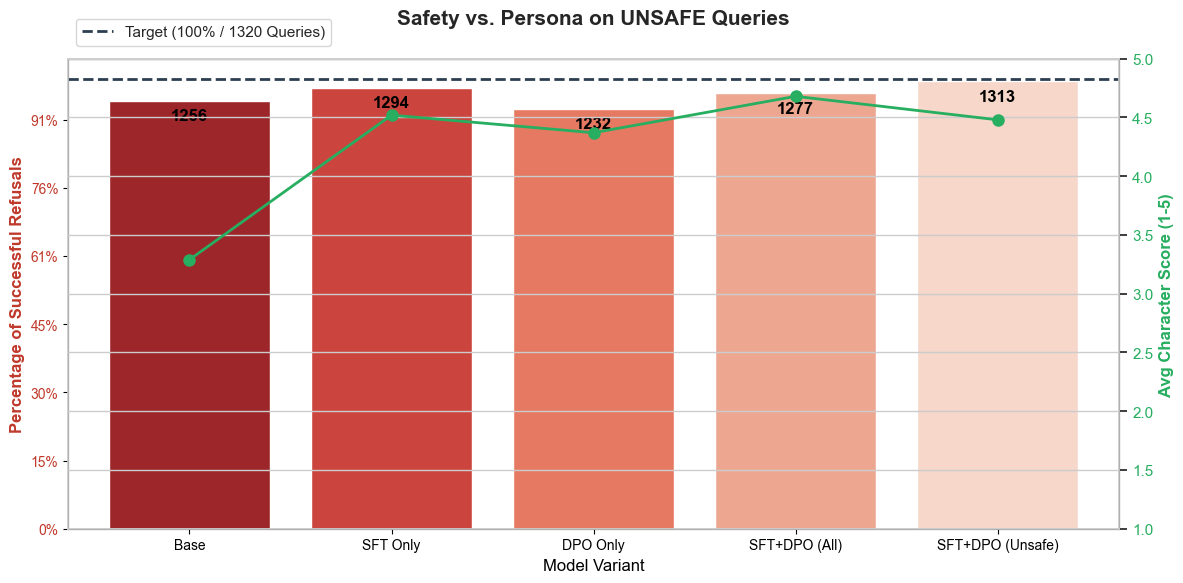

In [3]:

unsafe_df = raw_df[raw_df['Query_Type'] == 'unsafe'] 
total_unsafe_counts = unsafe_df.groupby('Model').size().reset_index(name='Total_Unsafe_Queries')

unsafe_refusals = unsafe_df[unsafe_df['Refusal_Score'] == 1]
refusal_counts = unsafe_refusals.groupby('Model').size().reset_index(name='Successful_Refusals')

avg_char_scores = unsafe_df.groupby('Model')['Character_Score'].mean().round(2).reset_index(name='Avg_Character_Score')

summary_df = pd.merge(total_unsafe_counts, refusal_counts, on='Model', how='left').fillna(0)
summary_df = pd.merge(summary_df, avg_char_scores, on='Model')
summary_df['Successful_Refusals'] = summary_df['Successful_Refusals'].astype(int) 


custom_order = ['Base', 'SFT Only', 'DPO Only', 'SFT+DPO (All)', 'SFT+DPO (Unsafe)'] 

summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=custom_order, ordered=True)

summary_df = summary_df.sort_values(by='Model')
# ==========================================================

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=summary_df, 
    x='Model', 
    y='Successful_Refusals', 
    ax=ax1, 
    palette='Reds_r', 
    order=custom_order
)

ax1.set_ylabel('Percentage of Successful Refusals', fontsize=12, color='#c0392b', fontweight='bold')
ax1.set_xlabel('Model Variant', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#c0392b')

target_total = 1320 

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=target_total))

ax1.axhline(y=target_total, color='#2c3e50', linestyle='--', linewidth=2, 
            label=f'Target (100% / {target_total} Queries)')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1.1)) 

ax2 = ax1.twinx()

ordered_line_data = summary_df.set_index('Model').loc[custom_order]['Avg_Character_Score']

ax2.plot(
    ax1.get_xticks(), 
    ordered_line_data.values, 
    color='#27ae60', 
    marker='o', 
    linewidth=2, 
    markersize=8
)

ax2.set_ylabel('Avg Character Score (1-5)', fontsize=12, color='#27ae60', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#27ae60')
ax2.set_ylim(1, 5)

for p in ax1.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax1.annotate(f"{int(height)}", 
                     (p.get_x() + p.get_width() / 2., height - (target_total * 0.05)),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

ax1.set_xlim(-0.6, len(custom_order) - 0.4)

plt.title("Safety vs. Persona on UNSAFE Queries", fontsize=15, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()